<a href="https://colab.research.google.com/github/mohamed5-jpg/N8n/blob/main/CNN_LSTMstrategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# جلب الذهب، الفضة، ومؤشر الدولار
tickers = ["GC=F", "SI=F", "DX-Y.NYB"]
data = yf.download(tickers, start="2015-01-01", end="2026-04-11")['Close']

# تنظيف البيانات وتسمية الأعمدة
data.columns = ['Dollar_Index', 'Gold', 'Silver']
data.fillna(method='ffill', inplace=True)

# إضافة مؤشر فني قوي: RSI (مؤشر القوة النسبية) للذهب
delta = data['Gold'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['Gold_RSI'] = 140 - (100 / (1 + rs))

data.dropna(inplace=True)
print(data.tail())

/tmp/ipykernel_8730/2475105787.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2026-04-11")['Close']
[*********************100%***********************]  3 of 3 completed

            Dollar_Index         Gold     Silver   Gold_RSI
Date                                                       
2026-04-06     99.980003  4656.799805  72.661003  78.594231
2026-04-07     99.639999  4657.100098  71.825996  78.314652
2026-04-08     99.129997  4749.500000  75.223999  85.167956
2026-04-09     98.820000  4792.200195  76.277000  97.937490
2026-04-10     98.650002  4761.899902  76.323997  97.937490



/tmp/ipykernel_8730/2475105787.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [ ]:
# الاحتفاظ بأسعار الفتح، الأعلى، الأدنى، الإغلاق، وحجم التداول
gold_data = gold_data[['Open', 'High', 'Low', 'Close', 'Volume']]

In [ ]:
# حساب العوائد اليومية بناءً على سعر الإغلاق
gold_data['Daily_Return'] = gold_data['Close'].pct_change()

In [ ]:
# حساب المتوسط المتحرك البسيط لـ 20 و 50 يوماً
gold_data['SMA_20'] = gold_data['Close'].rolling(window=20).mean()
gold_data['SMA_50'] = gold_data['Close'].rolling(window=50).mean()

In [ ]:
# حساب التقلب بناءً على الانحراف المعياري للعوائد لـ 20 يوماً
gold_data['Volatility_20'] = gold_data['Daily_Return'].rolling(window=20).std()

In [ ]:
# إزالة الصفوف التي تحتوي على قيم NaN
gold_data.dropna(inplace=True)

# طباعة آخر 5 أسطر للتأكد من نجاح العملية
print(gold_data.tail())

Price              Open         High          Low        Close  Volume
Date                                                                  
2026-04-06  4656.100098  4689.600098  4605.000000  4656.799805     148
2026-04-07  4624.899902  4676.299805  4608.000000  4657.100098     327
2026-04-08  4760.000000  4851.000000  4738.799805  4749.500000     405
2026-04-09  4711.000000  4799.100098  4711.000000  4792.200195    1277
2026-04-10  4745.899902  4791.000000  4744.899902  4761.899902    1277


/tmp/ipykernel_8730/760064996.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data.dropna(inplace=True)


In [ ]:

from sklearn.preprocessing import MinMaxScaler

# تحديد الهدف الذي نريد التنبؤ به (سعر الإغلاق)
target_col = 'Close'
feature_cols = gold_data.columns

# تهيئة أداة التسوية
scaler = MinMaxScaler(feature_range=(0, 1))

# تطبيق التسوية على جميع البيانات
scaled_data = scaler.fit_transform(gold_data)

# إعادتها إلى شكل DataFrame لتنظيمها
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols, index=gold_data.index)

In [ ]:

# تحديد طول النافذة الزمنية (60 يوماً)
sequence_length = 60

X = []
y = []

# إيجاد رقم العمود الخاص بسعر الإغلاق
target_index = gold_data.columns.get_loc(target_col)

# بناء المصفوفات (الحلقات التكرارية تمرر نافذة الـ 60 يوماً على طول البيانات)
for i in range(sequence_length, len(scaled_data)):
    # جلب جميع الميزات (الأسعار، العوائد، المؤشرات) للـ 60 يوماً السابقة
    X.append(scaled_data[i-sequence_length:i, :])
    # جلب سعر الإغلاق فقط لليوم المستهدف
    y.append(scaled_data[i, target_index])

# تحويل القوائم إلى مصفوفات Numpy لتكون جاهزة لـ Keras/TensorFlow
X, y = np.array(X), np.array(y)

print(f"شكل مصفوفة الإدخال (X): {X.shape}")
# النتيجة المتوقعة: (عدد العينات، 60 يوم، عدد الميزات)

print(f"شكل مصفوفة الهدف (y): {y.shape}")
# النتيجة المتوقعة: (عدد العينات،)

شكل مصفوفة الإدخال (X): (6317, 60, 5)
شكل مصفوفة الهدف (y): (6317,)


In [ ]:

# تحديد نسبة بيانات التدريب (مثلاً 80% للتدريب و 20% للاختبار)
train_size = int(len(X) * 0.8)

# تقسيم مصفوفة الإدخال (X)
X_train = X[:train_size]
X_test = X[train_size:]

# تقسيم مصفوفة الهدف (y)
y_train = y[:train_size]
y_test = y[train_size:]

print(f"عدد عينات التدريب: {len(X_train)}")
print(f"عدد عينات الاختبار: {len(X_test)}")

عدد عينات التدريب: 5053
عدد عينات الاختبار: 1264


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# تهيئة النموذج المتسلسل
model = Sequential()

# 1. طبقة CNN (لاستخراج الخصائص المحلية من حركة السعر والمؤشرات)
# نستخدم Conv1D لأن البيانات عبارة عن سلاسل زمنية في اتجاه واحد
model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# 2. طبقة LSTM (لتذكر الاتجاهات الزمنية الطويلة والقصيرة)
model.add(LSTM(units=50, activation='relu'))

# 3. طبقة Dropout (لمنع التكيف المفرط - Overfitting)
# تعطل 20% من الخلايا العصبية عشوائياً لضمان تعميم النموذج وليس حفظه للبيانات
model.add(Dropout(0.2))

# 4. طبقة الإخراج (Dense)
# خلية واحدة لأننا نتوقع قيمة مفردة (السعر المستقبلي)
model.add(Dense(units=1))

# تجميع النموذج (Compilation)
# نستخدم 'adam' لأنه فعال جداً، ودالة 'mean_squared_error' لقياس خطأ التوقع
model.compile(optimizer='adam', loss='mean_squared_error')

# عرض ملخص لمعمارية الشبكة وعدد المعلمات (Parameters) التي سيتم تدريبها
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 58, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,075 (94.04 KB)

 Trainable params: 24,075 (94.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# تحديد متغيرات التدريب
epochs = 50        # عدد مرات مرور النموذج على مجموعة البيانات بالكامل للتعلم
batch_size = 32    # عدد السلاسل الزمنية التي يعالجها النموذج في الدفعة الواحدة قبل تحديث أوزانه

# بدء عملية التدريب وحفظ سجل الأداء في المتغير 'history'
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),  # تمرير بيانات الاختبار لمراقبة الأداء ومنع التكيف المفرط
    verbose=1
)

Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 2.2067e-04 - val_loss: 0.0026
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 2.2809e-04 - val_loss: 0.0045
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.3100e-04 - val_loss: 0.0030
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 2.2350e-04 - val_loss: 0.0050
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.2581e-04 - val_loss: 0.0054
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.4088e-04 - val_loss: 0.0056
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2.2150e-04 - val_loss: 0.0039
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 2.1697e-04 - val_loss: 0.0068
Epoch 9/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.2384e-04 - val_loss: 0.0054
Epoch 10/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.3239e-04 - val_loss: 0.0041
Epoch 11/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.4268e-04 - val_loss: 0.00

In [ ]:

# 1. التنبؤ بأسعار الذهب باستخدام بيانات الاختبار
predicted_prices_scaled = model.predict(X_test)

# 2. عكس عملية التسوية (Inverse Transform) لنحصل على الأسعار الحقيقية
# ننشئ مصفوفة فارغة بنفس شكل البيانات الأصلية (عدد الصفوف × عدد الميزات)
prediction_copies = np.zeros(shape=(len(predicted_prices_scaled), gold_data.shape[1]))

# نضع التنبؤات في العمود المخصص لسعر الإغلاق
prediction_copies[:, target_index] = predicted_prices_scaled[:, 0]

# نعكس التسوية لاستخراج الأسعار المتوقعة بالدولار
predicted_prices = scaler.inverse_transform(prediction_copies)[:, target_index]

# 3. نفعل نفس الشيء للأسعار الحقيقية (y_test) لكي نتمكن من مقارنتها
actual_copies = np.zeros(shape=(len(y_test), gold_data.shape[1]))
actual_copies[:, target_index] = y_test
actual_prices = scaler.inverse_transform(actual_copies)[:, target_index]

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


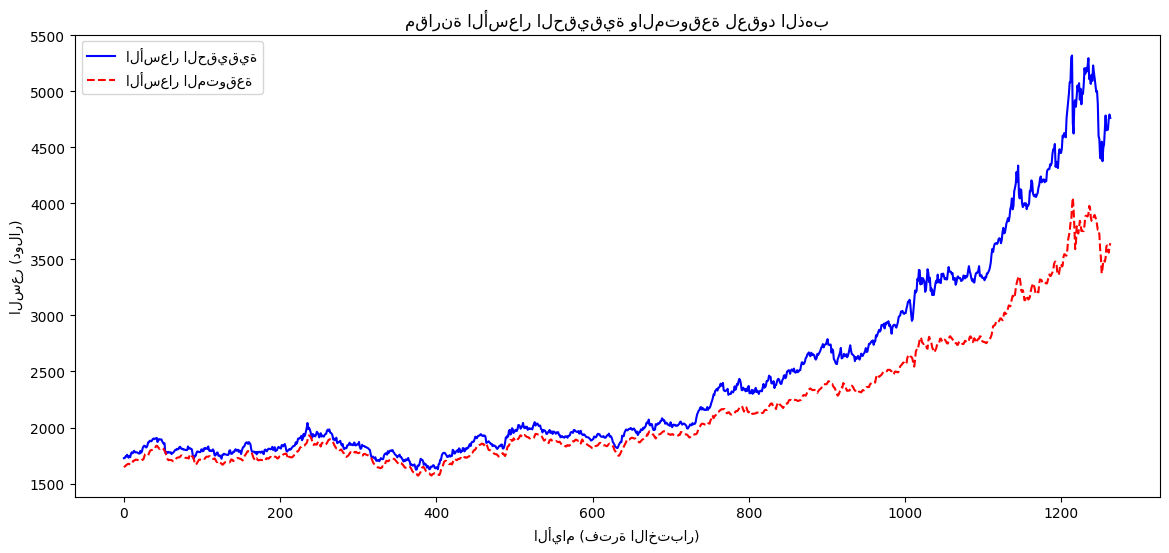

In [ ]:

import matplotlib.pyplot as plt

# إعداد حجم الرسم البياني
plt.figure(figsize=(14, 6))

# رسم الأسعار الحقيقية للذهب (باللون الأزرق)
plt.plot(actual_prices, color='blue', label='الأسعار الحقيقية')

# رسم الأسعار المتوقعة من نموذج CNN-LSTM (باللون الأحمر المتقطع)
plt.plot(predicted_prices, color='red', linestyle='dashed', label='الأسعار المتوقعة')

# إضافة العناوين والتفاصيل التوضيحية
plt.title('مقارنة الأسعار الحقيقية والمتوقعة لعقود الذهب')
plt.xlabel('الأيام (فترة الاختبار)')
plt.ylabel('السعر (دولار)')
plt.legend()

# إظهار الرسم البياني
plt.show()

In [ ]:

# 1. تحديد الهدف: 1 إذا كان السعر بعد 3 أيام أعلى بنسبة 1% من سعر اليوم، و0 خلاف ذلك
look_ahead = 3
profit_target = 0.01

gold_data['Target_Label'] = np.where(
    (gold_data['Close'].shift(-look_ahead) > gold_data['Close'] * (1 + profit_target)),
    1, 0
)

# 2. تحديث مصفوفة y لتستخدم التصنيف (Classification)
y = gold_data['Target_Label'].values[sequence_length:-look_ahead]
X = X[:-look_ahead] # موازنة مصفوفة X

/tmp/ipykernel_8730/2166447190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data['Target_Label'] = np.where(


In [ ]:

from tensorflow.keras.layers import Dense, Softmax

# تغيير الطبقة الأخيرة من خلية واحدة إلى خليتين (صعود / لا صعود)
model.add(Dense(2, activation='softmax'))

# تغيير دالة الخسارة لتعامل مع التصنيف
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:

# الحصول على الاحتمالات من النموذج
probabilities = model.predict(X_test)

# إعادة إنشاء DataFrame للنتائج للتأكد من الطول الصحيح والمحاذاة
# بيانات الاختبار في gold_data تتوافق مع البيانات المستخدمة لـ y_test و X_test
test_start_index_in_gold_data = train_size + sequence_length
results_gold_data_slice = gold_data.iloc[test_start_index_in_gold_data:].copy()

# Ensure 'Daily_Return' is present in results_gold_data_slice
results_gold_data_slice['Daily_Return'] = results_gold_data_slice['Close'].pct_change()

results_df = pd.DataFrame({
    'Actual': actual_prices,
    'Predicted': predicted_prices,
    'Actual_Return': results_gold_data_slice['Daily_Return'].values
}, index=results_gold_data_slice.index)

# قرار الدخول: نشتري فقط إذا كانت احتمالية الصعود > 50%
results_df['Signal'] = np.where(probabilities[:, 1] > 0.50, 1, 0)

# حساب العائد: إذا دخلنا، نحصد عائد الـ 3 أيام القادمة
results_df['Strategy_Return'] = results_df['Signal'] * results_df['Actual_Return'].rolling(window=3).sum().shift(-3)
results_df['Strategy_Return'] = results_df['Strategy_Return'].fillna(0)

# حساب العوائد التراكمية اللازمة للتحليل في الخلية التالية
results_df['Cumulative_Market_Return'] = (1 + results_df['Actual_Return']).cumprod()
results_df['Net_Strategy_Return'] = results_df['Strategy_Return'] # افتراض عدم وجود تكاليف تداول
results_df['Cumulative_Net_Strategy_Return'] = (1 + results_df['Net_Strategy_Return']).cumprod()


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


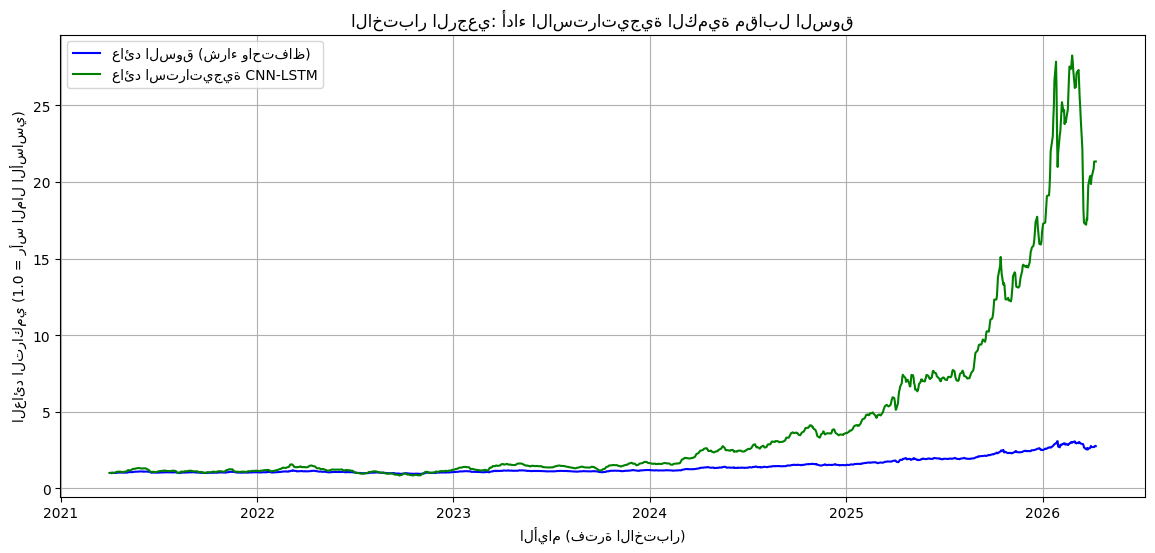

In [148]:

plt.figure(figsize=(14, 6))

# رسم عائد السوق (الاحتفاظ بالذهب بدون تداول نشط)
plt.plot(results_df['Cumulative_Market_Return'], color='blue', label='عائد السوق (شراء واحتفاظ)')

# رسم عائد النموذج الآلي
plt.plot(results_df['Cumulative_Net_Strategy_Return'], color='green', label='عائد استراتيجية CNN-LSTM')

plt.title('الاختبار الرجعي: أداء الاستراتيجية الكمية مقابل السوق')
plt.xlabel('الأيام (فترة الاختبار)')
plt.ylabel('العائد التراكمي (1.0 = رأس المال الأساسي)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# 1. حساب إجمالي العائد (Total Return)
total_market_return = (results_df['Cumulative_Market_Return'].iloc[-1] - 1) * 100
total_strategy_return = (results_df['Cumulative_Net_Strategy_Return'].iloc[-1] - 1) * 100

# 2. حساب نسبة شارب (Sharpe Ratio) - تقيس الربح مقابل المخاطرة
# نفترض أن نسبة العائد الخالي من المخاطر 0 (Risk-free rate)
daily_strategy_returns = results_df['Net_Strategy_Return']
sharpe_ratio = (daily_strategy_returns.mean() / daily_strategy_returns.std()) * np.sqrt(252)

# 3. حساب أقصى تراجع (Maximum Drawdown) - أكبر خسارة من القمة إلى القاع
rolling_max = results_df['Cumulative_Net_Strategy_Return'].cummax()
drawdown = (results_df['Cumulative_Net_Strategy_Return'] - rolling_max) / rolling_max
max_drawdown = drawdown.min() * 100

# 4. نسبة الصفقات الرابحة (Win Rate)
win_rate = (results_df['Net_Strategy_Return'] > 0).sum() / len(results_df) * 100

print(f"--- تقرير الأداء الرقمي ---")
print(f"إجمالي عائد السوق: {total_market_return:.2f}%")
print(f"إجمالي عائد الاستراتيجية الصافي: {total_strategy_return:.2f}%")
print(f"نسبة شارب (Sharpe Ratio): {sharpe_ratio:.2f}")
print(f"أقصى تراجع (Max Drawdown): {max_drawdown:.2f}%")
print(f"نسبة الصفقات الرابحة (Win Rate): {win_rate:.2f}%")


--- تقرير الأداء الرقمي ---
إجمالي عائد السوق: 175.81%
إجمالي عائد الاستراتيجية الصافي: 2033.46%
نسبة شارب (Sharpe Ratio): 2.21
أقصى تراجع (Max Drawdown): -46.27%
نسبة الصفقات الرابحة (Win Rate): 55.30%
